# Whakaari Dataset Construction

This notebook builds the Whakaari case-study dataset for Cause–Trigger analysis. It combines waveform-derived hydrothermal/seismic features with weather, gas, and deformation variables on a common hourly grid.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/whakaari"
sys.path.append(str(SRC_DIR))

from whakaari_config import (
    WHAKAARI_START,
    WHAKAARI_END,
    WHAKAARI_ERUPTION_TIME,
    TILDE_SUMMARY_URL,
    TILDE_DATA_URL,
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_WAVEFORM_CONFIG,
    WHAKAARI_EQ_RADIUS_KM,
    WHAKAARI_EQ_MIN_MAGNITUDE,
)

from whakaari_geonet import (
    load_so2_flux,
    load_gnss_deformation,
    load_weather_vars,
    load_local_earthquake_counts,
)

from whakaari_waveform import build_waveform_dataset

from whakaari_dataset import (
    build_master_dataframe,
    prepare_analysis_dataframe,
    scale_analysis_dataframe,
    save_whakaari_datasets,
)

from whakaari_plotting_utils import (
    dataset_health_report,
    plot_with_eruption_time,
    WHAKAARI_ALL_COLS,
)

client = Client("GEONET")

## 1. GeoNet and external data + local earthquake counts

We retrieve SO₂ flux and GNSS deformation from GeoNet/Tilde, and hourly weather variables from Open-Meteo. API and pressure drop are derived as hydrothermal forcing proxies.

In [2]:
so2 = load_so2_flux(TILDE_DATA_URL, WHAKAARI_START, WHAKAARI_END)
gnss = load_gnss_deformation(TILDE_DATA_URL, WHAKAARI_START, WHAKAARI_END)
weather_vars = load_weather_vars(
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_START,
    WHAKAARI_END,
)

In [3]:
local_eq, local_eq_events = load_local_earthquake_counts(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    latitude=WHAKAARI_LAT,
    longitude=WHAKAARI_LON,
    radius_km=WHAKAARI_EQ_RADIUS_KM,
    min_magnitude=WHAKAARI_EQ_MIN_MAGNITUDE,
    master_freq="1h",
)

print(local_eq.shape)
display(local_eq.head())
display(local_eq.describe())

print("Event catalogue rows:", len(local_eq_events))
display(local_eq_events.head())

(1704, 2)


,local_eq_count_1h,local_eq_count_24h
timestamp,,
2019-10-01 00:00:00+00:00,0.0,0.0
2019-10-01 01:00:00+00:00,0.0,0.0
2019-10-01 02:00:00+00:00,0.0,0.0
2019-10-01 03:00:00+00:00,0.0,0.0
2019-10-01 04:00:00+00:00,0.0,0.0


,local_eq_count_1h,local_eq_count_24h
count,1704.00000,1704.000000
mean,0.02230,0.535211
std,0.15545,0.942843
min,0.00000,0.000000
25%,0.00000,0.000000
50%,0.00000,0.000000
75%,0.00000,1.000000
max,2.00000,6.000000


Event catalogue rows: 38


,timestamp,latitude,longitude,depth_km,magnitude
0,2019-10-03 08:31:16.157187+00:00,-37.492023,177.349884,91.318359,1.952178
1,2019-10-03 21:59:14.988377+00:00,-37.507122,177.160019,113.641197,2.438961
2,2019-10-04 15:32:48.040216+00:00,-37.538536,177.218445,4.208585,2.064422
3,2019-10-06 00:47:35.187462+00:00,-37.349205,177.316757,5.000000,2.284503
4,2019-10-06 09:21:59.040931+00:00,-37.413063,176.964996,118.466621,2.211119


<Axes: title={'center': 'Local earthquake count, rolling 24h'}, xlabel='timestamp'>

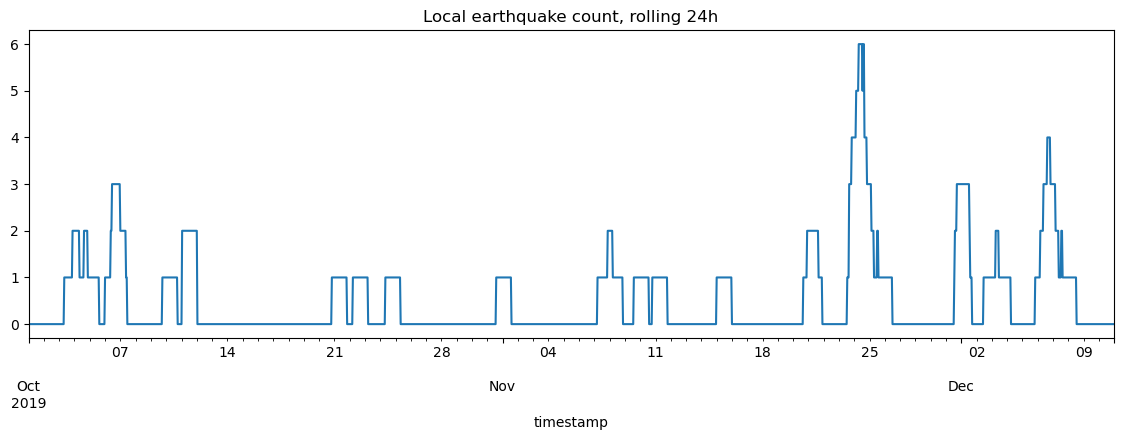

In [4]:
local_eq["local_eq_count_24h"].plot(
    figsize=(14, 4),
    title="Local earthquake count, rolling 24h"
)

## 2. Waveform feature extraction

Waveform data from WSRZ are processed into hourly seismic features: hydrothermal tremor RMS, spectral ratio, HF event rate, and a continuous tremor-response energy variable.

In [5]:
WHAKAARI_WAVEFORM_PKL = "../whakaari_data/whakaari_waveform.pkl"

waveform_df, waveform_failures = build_waveform_dataset(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    cfg=WHAKAARI_WAVEFORM_CONFIG,
    save_path=WHAKAARI_WAVEFORM_PKL,
    overwrite=False, # True will re-download and process waveforms, False will load from pkl
)

loaded cached waveform dataset: ..\whakaari_data\whakaari_waveform.pkl


## 3. Final hourly dataset

All variables are aligned to a common hourly timeline. Missing values are handled according to variable type, and the final dataset is saved in raw and scaled forms.

In [6]:
whakaari_raw = build_master_dataframe(
    wave=waveform_df,
    weather_vars=weather_vars,
    so2=so2,
    gnss=gnss,
    local_eq=local_eq,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    master_freq="1h",
)

whakaari_dataset = prepare_analysis_dataframe(whakaari_raw)

whakaari_dataset_scaled, analysis_prepped, scaler = scale_analysis_dataframe(
    whakaari_dataset
)

save_whakaari_datasets(
    whakaari_raw=whakaari_raw,
    whakaari_dataset=whakaari_dataset,
    whakaari_dataset_scaled=whakaari_dataset_scaled,
    output_dir="../whakaari_data",
)

In [7]:
#load datasets for analysis
#whakaari_raw = pd.read_csv("../whakaari_data/whakaari_raw.csv", parse_dates=["timestamp"]).set_index("timestamp")
#whakaari_dataset = pd.read_csv("../whakaari_data/whakaari_dataset.csv", parse_dates=["timestamp"]).set_index("timestamp")
#whakaari_dataset_scaled = pd.read_csv("../whakaari_data/whakaari_dataset_scaled.csv", parse_dates=["timestamp"]).set_index("timestamp")

## 4. Dataset checks

We inspect missingness, summary statistics, and timestamp consistency before using the dataset for causal discovery.

In [8]:
display(dataset_health_report(whakaari_raw, "Whakaari whakaari_raw"))
display(dataset_health_report(whakaari_dataset, "Whakaari whakaari_dataset"))
display(dataset_health_report(whakaari_dataset_scaled, "Whakaari whakaari_dataset_scaled"))


Whakaari whakaari_raw
shape: (1704, 10)
duplicate timestamps: 0
time sorted: True

Missing fraction:
local_eq_count_24h        0.000000
local_eq_count_1h         0.000000
pressure_drop             0.000587
API                       0.000587
effect_tremor_rms_5_15    0.002347
hf_event_rate_2_5         0.002347
hydro_rms_2_5             0.002347
ratio_4p5_8_over_8_16     0.002347
GNSS_deformation          0.013498
SO2_flux                  0.874413
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h,local_eq_count_24h
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.703000e+03,1703.000000,214.000000,1681.000000,1704.00000,1704.000000
mean,1.945570e-06,1.641214,7.651176,3.891592e-06,1.016480e-01,-0.000881,4.376665,0.012930,0.02230,0.535211
std,7.967279e-07,0.465081,7.186089,1.219615e-06,1.975290e-01,0.471708,3.769987,0.003082,0.15545,0.942843
min,4.953468e-07,0.495936,0.000000,9.023087e-07,6.925921e-07,-1.900000,0.084491,0.004500,0.00000,0.000000
25%,1.468574e-06,1.343117,3.000000,3.002514e-06,3.751486e-03,-0.300000,1.726030,0.010700,0.00000,0.000000
50%,1.679596e-06,1.741087,6.000000,3.780905e-06,2.298817e-02,0.000000,3.215885,0.013080,0.00000,0.000000
75%,2.340319e-06,1.946830,10.000000,4.564779e-06,8.760322e-02,0.300000,6.219676,0.015370,0.00000,1.000000
max,7.377315e-06,2.986552,65.000000,1.231605e-05,1.130858e+00,1.800000,20.699190,0.021210,2.00000,6.000000



Whakaari whakaari_dataset
shape: (1700, 10)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_24h        0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h,local_eq_count_24h
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.699000e+03,1700.000000,395.000000,1700.000000,1700.000000,1700.000000
mean,1.945570e-06,1.641214,7.651176,3.891592e-06,1.016528e-01,-0.001824,4.565517,0.012894,0.022353,0.536471
std,7.967279e-07,0.465081,7.186089,1.219615e-06,1.977613e-01,0.471585,3.840615,0.003075,0.155629,0.943594
min,4.953468e-07,0.495936,0.000000,9.023087e-07,6.925921e-07,-1.900000,0.084491,0.004500,0.000000,0.000000
25%,1.468574e-06,1.343117,3.000000,3.002514e-06,3.744668e-03,-0.300000,1.731297,0.010660,0.000000,0.000000
50%,1.679596e-06,1.741087,6.000000,3.780905e-06,2.289950e-02,-0.000000,3.446339,0.013080,0.000000,0.000000
75%,2.340319e-06,1.946830,10.000000,4.564779e-06,8.704657e-02,0.300000,6.447703,0.015370,0.000000,1.000000
max,7.377315e-06,2.986552,65.000000,1.231605e-05,1.130858e+00,1.800000,20.699190,0.021210,2.000000,6.000000



Whakaari whakaari_dataset_scaled
shape: (1700, 10)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_24h        0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h,local_eq_count_24h
count,1.700000e+03,1700.000000,1.700000e+03,1.700000e+03,1.699000e+03,1.700000e+03,3.950000e+02,1.700000e+03,1.700000e+03,1.700000e+03
mean,-1.003119e-16,0.000000,3.009357e-16,1.671865e-16,8.364246e-18,-6.269495e-18,1.618958e-16,4.346850e-16,2.507798e-17,-3.343731e-17
std,1.000294e+00,1.000294,1.000294e+00,1.000294e+00,1.000294e+00,1.000294e+00,1.001268e+00,1.000294e+00,1.000294e+00,1.000294e+00
min,-1.820763e+00,-2.463256,-2.302527e+00,-2.451732e+00,-5.763326e-01,-4.026286e+00,-2.205530e+00,-2.730876e+00,-1.436717e-01,-6.641053e-01
25%,-5.988704e-01,-0.641144,-5.843065e-01,-7.291975e-01,-5.508583e-01,-6.324721e-01,-7.767543e-01,-7.269102e-01,-1.436717e-01,-6.641053e-01
50%,-3.339317e-01,0.214808,1.093005e-01,-9.078195e-02,-4.219967e-01,3.867949e-03,-2.296611e-02,6.036200e-02,-1.436717e-01,-6.641053e-01
75%,4.956086e-01,0.657318,6.695064e-01,5.521301e-01,-7.377712e-03,6.402080e-01,7.749181e-01,8.053427e-01,-1.436717e-01,8.493616e-01
max,6.819559e+00,2.893546,2.890274e+00,6.909478e+00,4.580733e+00,3.821908e+00,2.429096e+00,2.705206e+00,1.271116e+01,3.584733e+00


## 5. Visual inspection

The final variables are plotted with the eruption time marked. This helps assess whether the causal-analysis window and variables are physically meaningful.

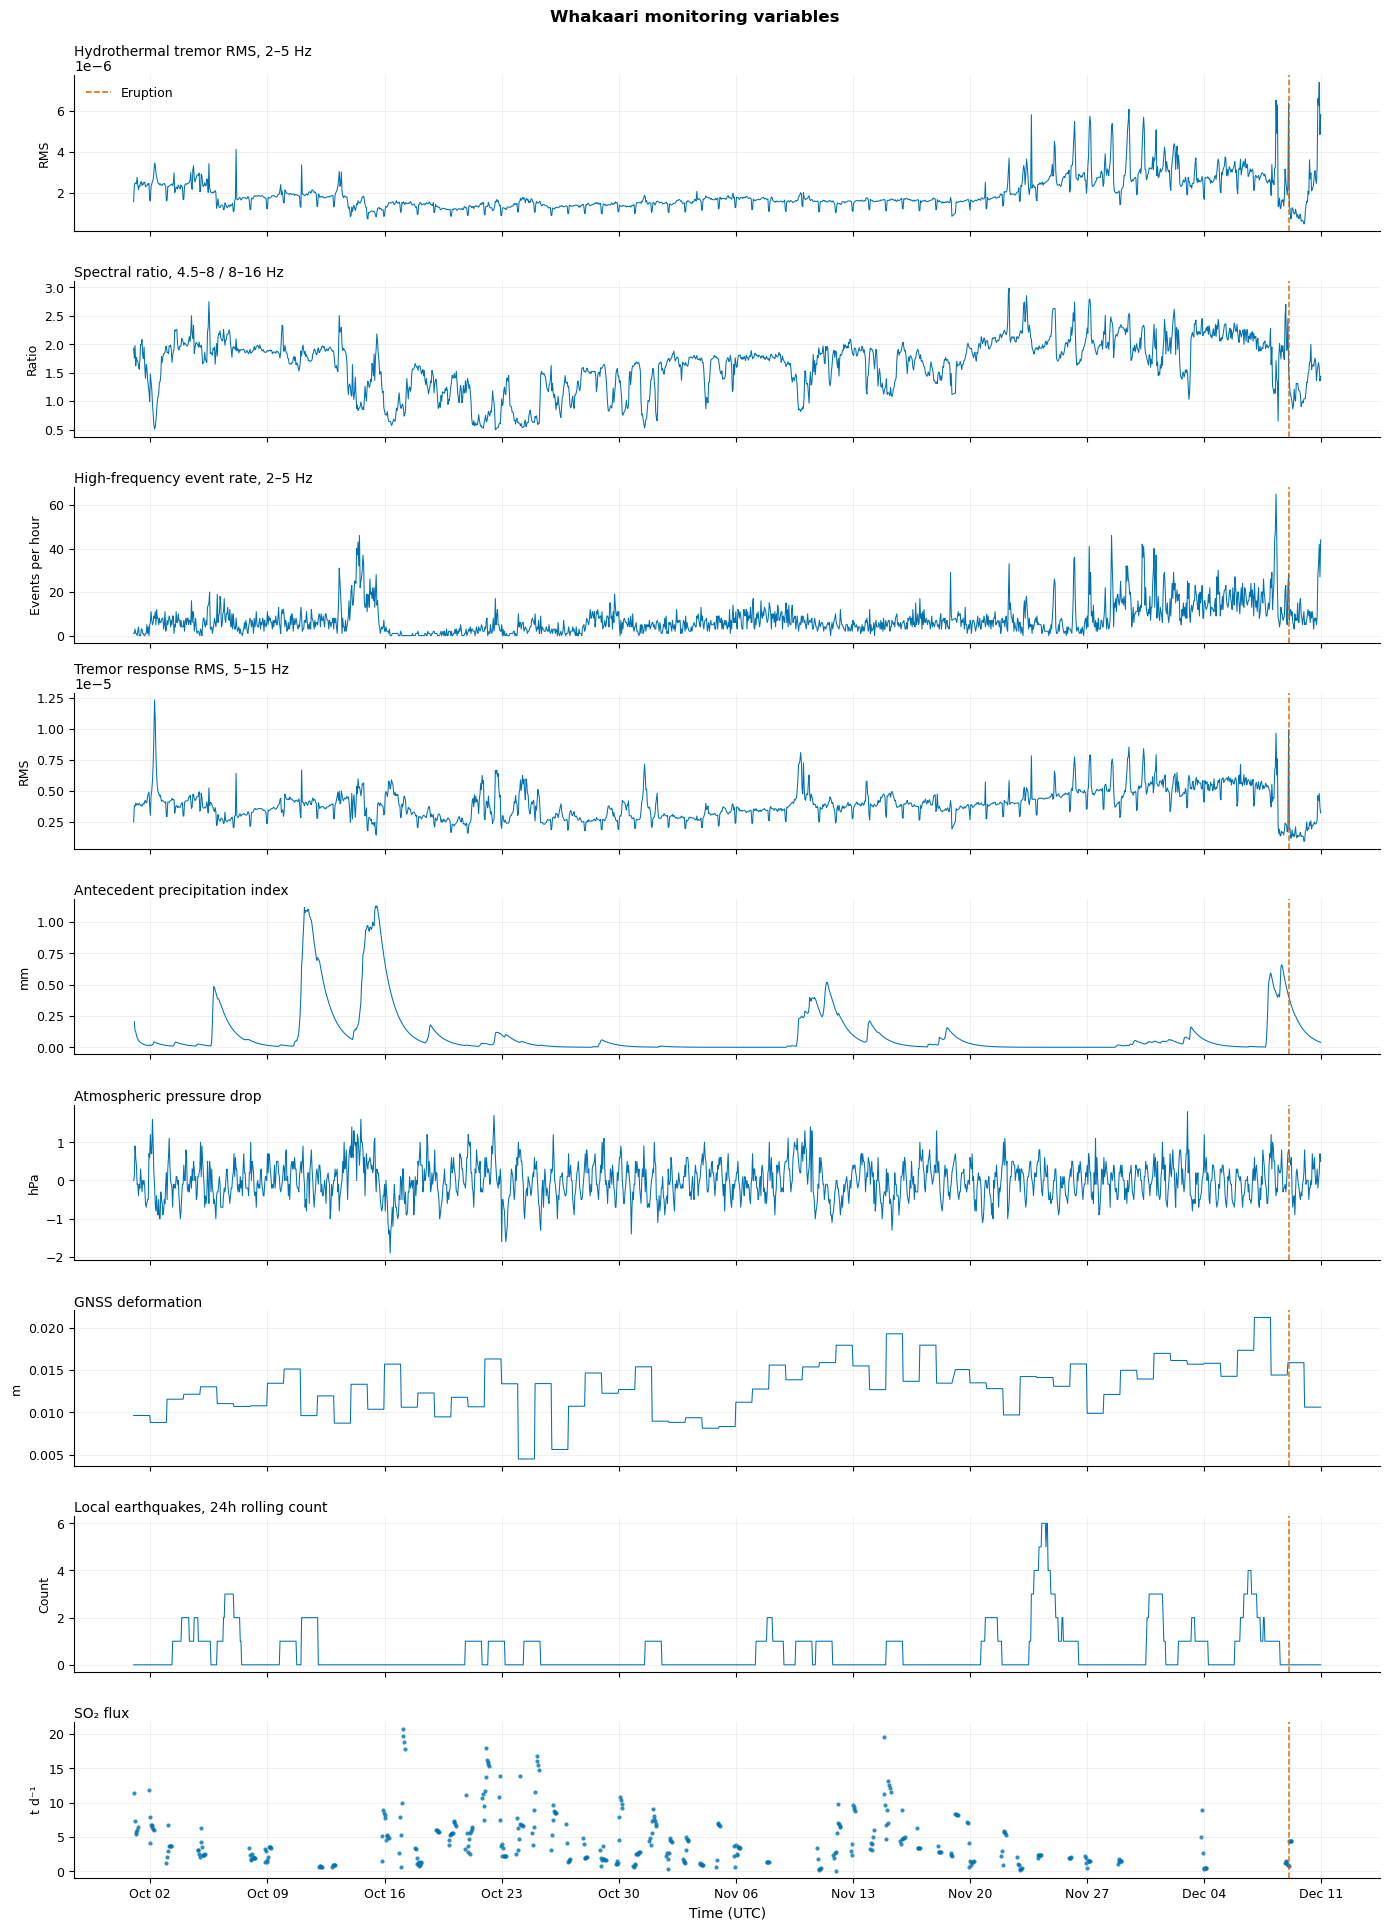

In [9]:
plot_with_eruption_time(
    "../whakaari_data/whakaari_dataset.csv",
    cols=WHAKAARI_ALL_COLS,
    eruption_time=WHAKAARI_ERUPTION_TIME,
    title="Whakaari monitoring variables",
    tick_interval_days=7,
)